In [1]:
!pip install -q h2o pandas scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 4.4 MB/s eta 0:00:00


In [2]:
# Bouzid Mohamed El Khallil - ENSTA
import h2o
import pandas as pd
import numpy as np

from h2o.automl import H2OAutoML
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score


In [3]:
# Chargement du dataset
housing = fetch_california_housing()
features = pd.DataFrame(housing.data, columns=housing.feature_names)
target = pd.Series(housing.target, name="MedHouseVal")

# Standardisation des features
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.25, random_state=2024
)


In [4]:
h2o.init(max_mem_size="2G")

# Conversion en H2OFrame
train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train], axis=1))
test_h2o  = h2o.H2OFrame(pd.concat([X_test, y_test], axis=1))


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmptlsqowqs
  JVM stdout: /tmp/tmptlsqowqs/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmptlsqowqs/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,06 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 20 days
H2O_cluster_name:,H2O_from_python_unknownUser_vqw86u
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.979 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [5]:
aml = H2OAutoML(
    max_models=10,       # limite le nombre de modèles pour rapidité
    max_runtime_secs=60, # 1 minute
    seed=2024
)

aml.train(
    x=X_train.columns.tolist(),
    y="MedHouseVal",
    training_frame=train_h2o
)


AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_1_AutoML_1_20260113_203214


Model Summary: 
    number_of_trees
--  -----------------
    40

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 0.051670362258603386
RMSE: 0.2273111573561742
MAE: 0.16051478991224805
RMSLE: 0.0727385277812664
Mean Residual Deviance: 0.051670362258603386

ModelMetricsRegression: xgboost
** Reported on cross-validation data. **

MSE: 0.2577275170231217
RMSE: 0.5076687079416277
MAE: 0.34564936226468473
RMSLE: 0.15627254308994107
Mean Residual Deviance: 0.2577275170231217

Cross-Validation Metrics Summary: 
                        mean      sd          cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
----------------------  --------  ----------  ------------  ------------  ------------  ------------  ------------
aic                     nan       0           nan           nan           nan           nan           nan
loglikelihood           nan       0           nan           nan           nan           nan           nan
mae                     0.345649  0.00713213  0.335717      0.348234      0.354349      0.341692      0.348256
mean_residual_deviance  0.257727  0.00923536  0.248599      0.264236      0.269539      0.249025      0.257239
mse                     0.257727  0.00923536  0.248599      0.264236      0.269539      0.249025      0.257239
r2                      0.805263  0.00383969  0.809678      0.799796      0.805145      0.807958      0.803741
residual_deviance       0.257727  0.00923536  0.248599      0.264236      0.269539      0.249025      0.257239
rmse                    0.507604  0.00908464  0.498597      0.514039      0.519172      0.499024      0.507187
rmsle                   0.156255  0.00259426  0.153376      0.156511      0.160241      0.154639      0.156509

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------
    2026-01-13 20:32:38  23.046 sec  0                  1.94614          1.57106         3.78746
    2026-01-13 20:32:40  24.987 sec  5                  0.576664         0.394848        0.332541
    2026-01-13 20:32:40  25.771 sec  10                 0.369598         0.245874        0.136603
    2026-01-13 20:32:41  26.313 sec  15                 0.314971         0.211535        0.0992067
    2026-01-13 20:32:42  27.088 sec  20                 0.294628         0.200498        0.0868058
    2026-01-13 20:32:42  27.482 sec  25                 0.276794         0.191252        0.076615
    2026-01-13 20:32:43  28.006 sec  30                 0.262219         0.182357        0.0687588
    2026-01-13 20:32:43  28.286 sec  35                 0.241211         0.168936        0.0581829
    2026-01-13 20:32:43  28.775 sec  40                 0.227311         0.160515        0.0516704

Variable Importances: 
variable    relative_importance    scaled_importance    percentage
----------  ---------------------  -------------------  ------------
MedInc      9695.17                1                    0.38902
AveOccup    3364.63                0.347042             0.135006
AveRooms    3137.24                0.323588             0.125882
Latitude    2867.13                0.295728             0.115044
Longitude   2592.07                0.267357             0.104007
HouseAge    1526.3                 0.157429             0.0612431
AveBedrms   1030.76                0.106317             0.0413594
Population  708.704                0.0730987            0.0284369

[tips]
Use `model.explain()` to inspect the model.
--
Use `h2o.display.toggle_user_tips()` to switch on/off this section.

In [6]:
# Prédiction
pred_h2o = aml.predict(test_h2o).as_data_frame().values.flatten()

# Score R2
r2 = r2_score(y_test, pred_h2o)
print(f"R2 Score (H2O AutoML) = {r2:.4f}")


xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
R2 Score (H2O AutoML) = 0.8089


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


/tmp/ipython-input-3178640980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["H2O AutoML"], y=[r2], palette="viridis")


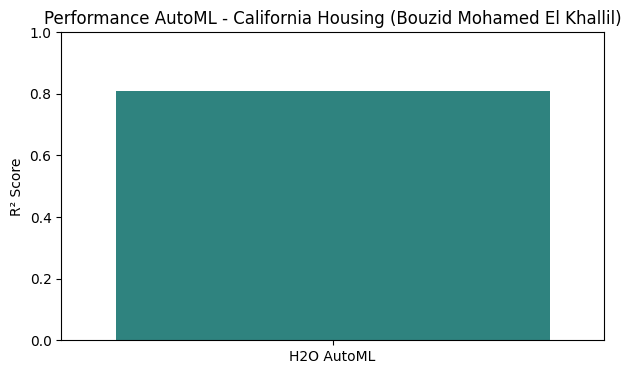

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(x=["H2O AutoML"], y=[r2], palette="viridis")
plt.ylim(0,1)
plt.title("Performance AutoML - California Housing (Bouzid Mohamed El Khallil)")
plt.ylabel("R² Score")
plt.show()
